In [1]:
import torch
from torch import nn
from torchsummary import summary
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import FashionMNIST



In [2]:
# 数据集构建
full_data = FashionMNIST(root='./data',train=True,transform=transforms.Compose([transforms.Resize(size=28),transforms.Grayscale(num_output_channels=1),transforms.ToTensor()]),download=True)#这里是1通道的灰度图
# 划分训练集和验证集 
train_data,val_data = Data.random_split(dataset=full_data,lengths=[round(0.8*len(full_data)),round(0.2*len(full_data))])
train_loader = Data.DataLoader(dataset=train_data,batch_size=256,shuffle=True,num_workers=0)
val_loader = Data.DataLoader(dataset=val_data,batch_size=256,shuffle=False,num_workers=0)
# 获得一个batch的数据
i=1
for batch_idx,(data,target) in enumerate(train_loader):
    if i>0:
      print(data.shape)
      print(target.shape)
      i-=1
    if batch_idx > 0:
      break
    batch_x = data.squeeze().numpy()#将四维张亮去掉第一维
    batch_y=target.numpy()
    class_label = train_data.dataset.classes#训练集的类别标签
    # 打印数据形状    
    print(batch_x.shape)
    print(batch_y.shape)
    print(class_label)


torch.Size([256, 1, 28, 28])
torch.Size([256])
(256, 28, 28)
(256,)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
# 模型搭建
class LetNet(nn.Module):
    def __init__(self):
        super(LetNet, self).__init__()
        self.c1 = nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,padding=2)
        self.sig = nn.Sigmoid()
        self.s2 = nn.AvgPool2d(kernel_size=2,stride=2)
        self.c3 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5)
        self.s4 = nn.AvgPool2d(kernel_size=2,stride=2)
        self.flatten = nn.Flatten()
        self.l5 = nn.Linear(16*5*5,120)
        self.l6 = nn.Linear(120,84)
        self.l7 = nn.Linear(84,10)
    #     新增优化
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self,x):
        x = self.sig(self.c1(x))
        x = self.s2(x)
        x=self.sig(self.c3(x))
        x =self.s4(x)
        x = self.flatten(x)
        x = self.l5(x)
        x = self.l6(x)
        x = self.l7(x)
        return x

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LetNet().to(device)
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
           Sigmoid-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
           Sigmoid-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
           Flatten-7                  [-1, 400]               0
            Linear-8                  [-1, 120]          48,120
            Linear-9                   [-1, 84]          10,164
           Linear-10                   [-1, 10]             850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.11
Params size (MB): 0.24
Estimated Tot

In [4]:
# 定义优化器和损失函数
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
criterion =nn.CrossEntropyLoss()#交叉熵用于分类


In [9]:
import pandas as pd
import copy
import torch
from torch.nn.modules import loss
from tqdm import tqdm 
import time

# 训练
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_loss_all = []
val_loss_all = []
train_acc_all = []
val_acc_all = []
epoch_num = 100

# ================= 1: 这里包裹最外层的 range =================
# total=epoch_num, unit='epoch' 让进度条显示为 "进度: 1/20 [00:10<03:00, ...]"
main_loop = tqdm(range(epoch_num), desc="Total Training", unit='epoch')

for epoch in main_loop:
    # 初始化每一轮的参数
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0
    train_num = 0
    val_num = 0     
    # ================= 训练阶段 =================
    model.train()
    for step, (b_x, b_y) in enumerate(train_loader): 
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        
        optimizer.zero_grad()
        output = model(b_x)
        pre_label = torch.argmax(output, 1)
        loss = criterion(output, b_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * b_x.size(0)
        train_acc += torch.sum(pre_label == b_y.data)
        train_num += b_x.size(0)

    # ================= 验证阶段 =================
    model.eval()
    for step, (b_x, b_y) in enumerate(val_loader):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        
        with torch.no_grad():
            output = model(b_x)
            pre_label = torch.argmax(output, 1)
            loss = criterion(output, b_y)
            val_loss += loss.item() * b_x.size(0)
            val_acc += torch.sum(pre_label == b_y.data)
            val_num += b_x.size(0)

    # 计算平均指标
    epoch_train_loss = train_loss / train_num
    epoch_train_acc = train_acc.double() / train_num
    epoch_val_loss = val_loss / val_num
    epoch_val_acc = val_acc.double() / val_num

    train_loss_all.append(epoch_train_loss)
    train_acc_all.append(epoch_train_acc)
    val_loss_all.append(epoch_val_loss)
    val_acc_all.append(epoch_val_acc)

    # 深度拷贝模型
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    # ================= 修改点 2: 在总进度条后面显示本轮结果 =================
    # 这样你就不用 print 了，直接看进度条末尾的数字即可
    main_loop.set_postfix(
        train_loss=f"{epoch_train_loss:.4f}", 
        train_acc=f"{epoch_train_acc:.4f}",
        val_acc=f"{epoch_val_acc:.4f}"
    )

# 保存模型
torch.save(best_model_wts, 'best_model.pth')

# 数据转换处理
train_process = pd.DataFrame(data={
    "epoch": range(epoch_num),
    "train_loss": train_loss_all,
    "val_loss": val_loss_all,
    "train_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in train_acc_all],
    "val_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in val_acc_all]
})

print("Training Complete. Data saved.")

Total Training: 100%|██████████| 20/20 [03:32<00:00, 10.63s/epoch, train_acc=0.8821, train_loss=0.3188, val_acc=0.8772]

Training Complete. Data saved.


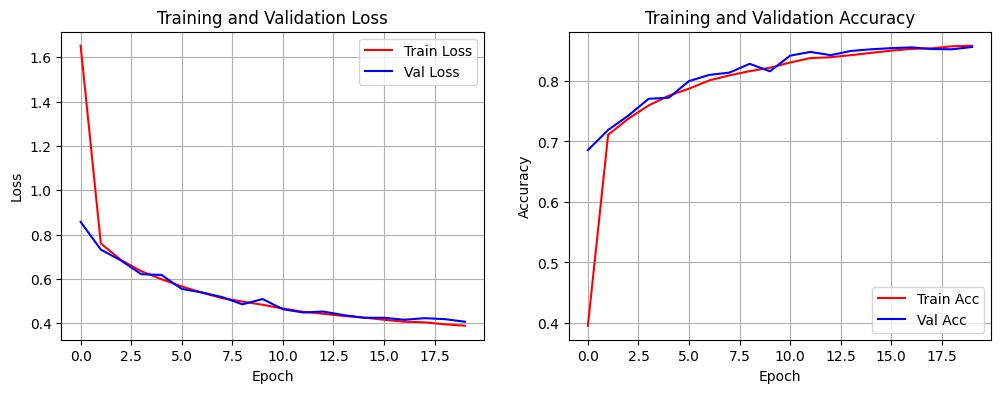

In [6]:
# ==========================================
# 3. 开始画图 (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 4)) # 设置画布大小：宽12，高4

# --- 第一张图：Loss (损失率) ---
plt.subplot(1, 2, 1) # 1行2列，第1张图
plt.plot(train_process['epoch'], train_process['train_loss'], 'r', label='Train Loss') # 红线
plt.plot(train_process['epoch'], train_process['val_loss'], 'b', label='Val Loss')   # 蓝线
plt.legend() # 显示图例
plt.grid(True) # 显示网格
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

# --- 第二张图：Accuracy (准确率) ---
plt.subplot(1, 2, 2) # 1行2列，第2张图
plt.plot(train_process['epoch'], train_process['train_acc'], 'r', label='Train Acc')
plt.plot(train_process['epoch'], train_process['val_acc'], 'b', label='Val Acc')
plt.legend()
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# 显示图表
plt.show()


In [7]:
# 预测展示
# 加载最佳模型权重
# 计算测试集准确率
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('best_model.pth',weights_only=True))
model.to(device)
model.eval()

test_data = FashionMNIST(root='./data', train=False,
                         transform=transforms.Compose([transforms.Resize(size=28), transforms.ToTensor()]),
                         download=True)
test_loader = Data.DataLoader(dataset=test_data, batch_size=1, shuffle=True, num_workers=0)

correct = 0
total = 0
with torch.no_grad():#在测试时不计算梯度，节省内存
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)#第0维度的大小，即batch_size

print(f"Test Acc: {correct/total:.4f}")


Test Acc: 0.8495


In [8]:
# python
# 标签张量的形状和样本数示例这是于模型无关的代码
import torch

# 示例1：一维标签（常见）
labels1 = torch.tensor([0, 1, 2, 3])   # 4 个样本的标签
print(labels1.shape)       # 输出: torch.Size([4])
print(labels1.size(0))     # 输出: 4

# 示例2：二维标签（每个标签是列向量）
labels2 = torch.tensor([[0], [1], [2]])  # 3 个样本，每个标签为一列
print(labels2.shape)       # 输出: torch.Size([3, 1])
print(labels2.size(0))     # 输出: 3

# 示例3：DataLoader 场景（模拟 batch）
batch_size = 8
inputs = torch.randn(batch_size, 1, 28, 28)   # 输入张量
labels3 = torch.randint(0, 10, (batch_size,)) # 8 个标签
print(labels3.shape)       # 输出: torch.Size([8])
print(labels3.size(0))     # 输出: 8

# 常见用途：累加样本数用于计算准确率或平均损失
correct = 5
total = labels3.size(0)    # total = 8
accuracy = correct / total
print("accuracy =", accuracy)  # 输出: accuracy = 0.625

torch.Size([4])
4
torch.Size([3, 1])
3
torch.Size([8])
8
accuracy = 0.625
